In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("netflix_titles.csv", sep=None, engine='python')
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [4]:
df.shape

(8807, 12)

In [5]:
s = []
[s.append(val) for val in df["show_id"] if val not in s]
len(s)  # unique count
# show id is a primary key, each show has its unique show id.

8807

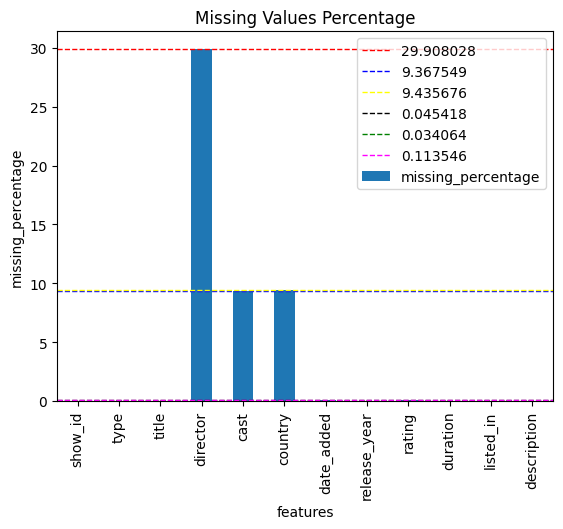

In [6]:
df_missing = df.count().to_frame(name="total_count")
df_missing["missing_percentage"]=df_missing["total_count"].apply(lambda x : ((len(df) - x)/len(df)) * 100)
df_missing["missing_percentage"].plot(kind="bar")
plt.axhline(y = 29.908028, color = "red", linewidth = 1, linestyle = "--", label="29.908028")
plt.axhline(y = 9.367549, color = "blue", linewidth = 1, linestyle = "--", label="9.367549")
plt.axhline(y = 9.435676, color = "yellow", linewidth = 1, linestyle = "--", label="9.435676")
plt.axhline(y = 0.045418, color = "black", linewidth = 1, linestyle = "--", label="0.045418")
plt.axhline(y = 0.034064, color = "green", linewidth = 1, linestyle = "--", label="0.034064")
plt.axhline(y = 0.113546, color = "magenta", linewidth = 1, linestyle = "--", label="0.113546")
plt.ylabel("missing_percentage")
plt.xlabel("features")
plt.title("Missing Values Percentage")
plt.legend()
plt.show()

In [ ]:
df["director"] = df["director"].fillna('Unspecified')
df["date_added"] = df["date_added"].fillna('Missing')

In [ ]:
df["duration"] = np.where(df["duration"].isnull(), df["rating"],df["duration"])
df["rating"] = np.where( df["rating"].isnull() | df["rating"].str.contains("min", na= False) | (df["rating"].isin(["NR", "UR"])), "Unrated",df["rating"])
df["country"] = np.where(df["country"].isnull(), "Unspecified",df["country"])
df["cast"] = np.where(df["cast"].isnull(), "Unspecified",df["cast"])

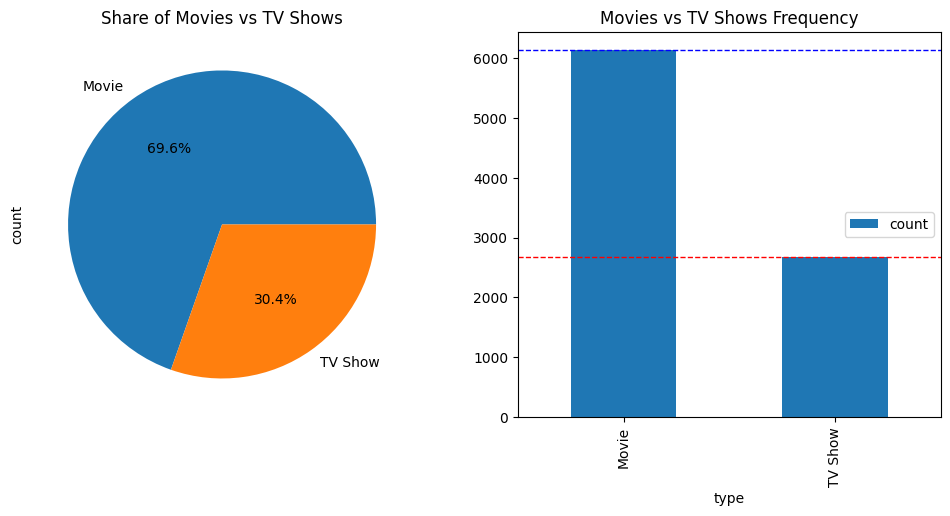

In [ ]:
fig, axes= plt.subplots(1 , 2, figsize = (12,5))
df["type"].value_counts().plot(kind = "pie", autopct = "%.1f%%", ax = axes[0])
axes[0].set_title("Share of Movies vs TV Shows")
df["type"].value_counts().plot(kind="bar", ax = axes[1])
axes[1].axhline(y=2680, color = 'red', linestyle = "--", linewidth = 1)
axes[1].axhline(y=6140, color = 'blue', linestyle = "--", linewidth = 1)
axes[1].set_title("Movies vs TV Shows Frequency")
plt.legend()
plt.show()

In [ ]:
# explode cast column into individual actors
df_exploded = df.assign(actor=df["cast"].str.split(",")).explode("actor")
df_exploded["actor"] = df_exploded["actor"].str.strip()



In [ ]:
df_exploded = df.assign(actor=df["cast"].str.split(",")).explode("actor")

In [ ]:
df_exploded

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,actor
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unspecified,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",Unspecified
1,s2,TV Show,Blood & Water,Unspecified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Ama Qamata
1,s2,TV Show,Blood & Water,Unspecified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Khosi Ngema
1,s2,TV Show,Blood & Water,Unspecified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Gail Mabalane
1,s2,TV Show,Blood & Water,Unspecified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",Thabang Molaba
...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Manish Chaudhary
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Meghna Malik
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Malkeet Rauni
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,Anita Shabdish


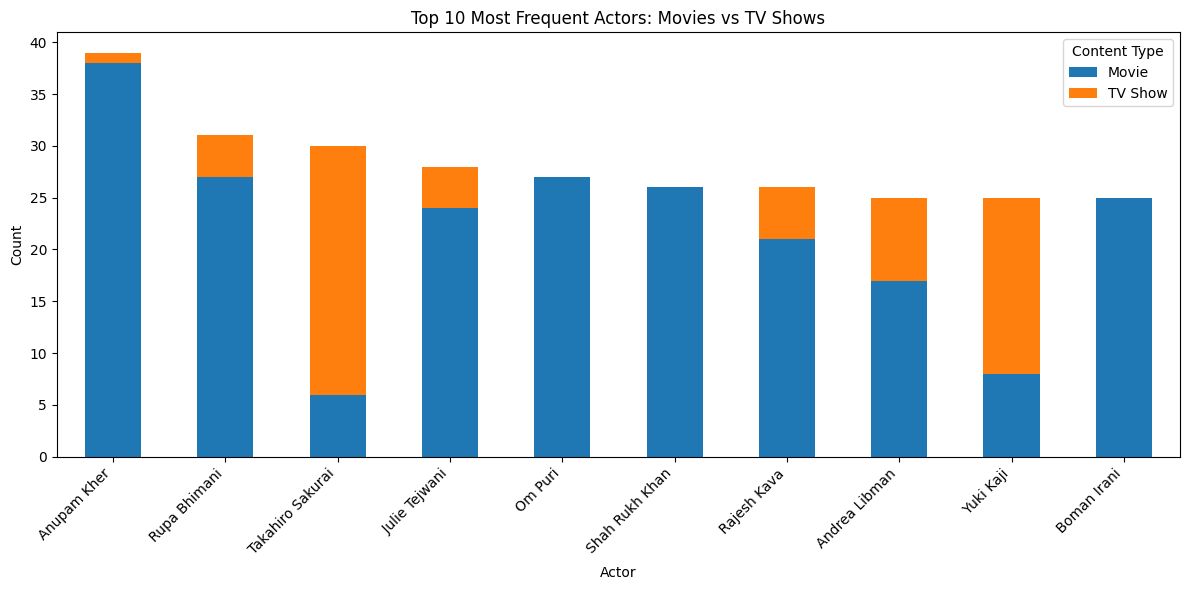

In [ ]:
# Aggregate actor counts by type
actor_type_counts = df_exploded[df_exploded["actor"] != "Unspecified"].groupby(['actor', 'type']).size().unstack(fill_value=0)

# Calculate total appearances for each actor to find overall top actors
actor_type_counts['total'] = actor_type_counts.sum(axis=1)

# Sort and get the top 10 actors overall
top_10_overall_actors = actor_type_counts.sort_values(by='total', ascending=False).head(10)

# Drop the 'total' column before plotting, as it's not needed for stacking
top_10_plot_data = top_10_overall_actors.drop(columns='total')

# Create the stacked bar chart
fig = plt.figure(figsize=(12, 6))
top_10_plot_data.plot(kind='bar', stacked=True, ax=plt.gca())
plt.title('Top 10 Most Frequent Actors: Movies vs TV Shows')
plt.xlabel('Actor')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Content Type')
plt.tight_layout()
plt.show()

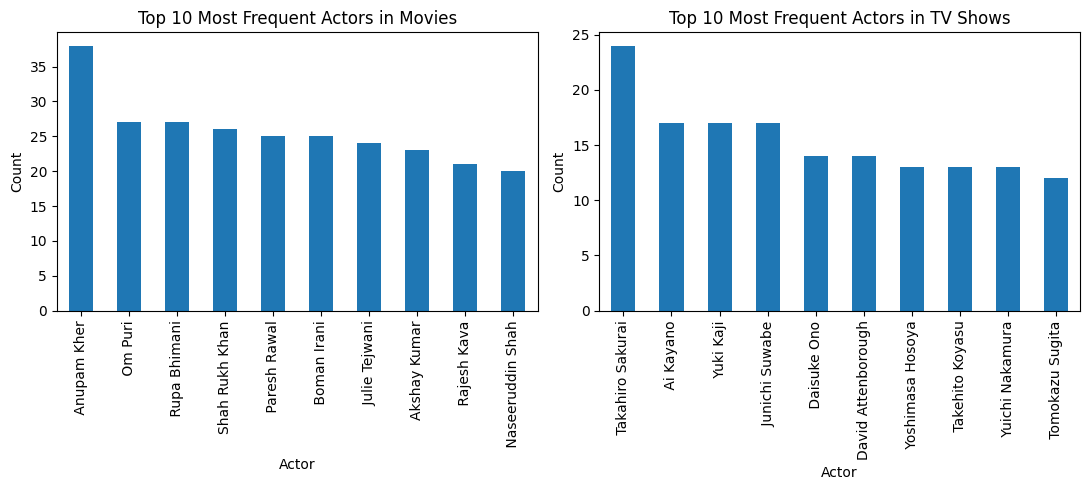

In [ ]:
fig, axes = plt.subplots(1 ,2 , figsize = (11, 5))
df_exploded[(df_exploded["type"] == "Movie") & (df_exploded["actor"] !=  "Unspecified")]["actor"].value_counts().head(10).plot(kind = "bar", ax = axes[0])
axes[0].set_title("Top 10 Most Frequent Actors in Movies")
axes[0].set_xlabel("Actor")
axes[0].set_ylabel("Count")

df_exploded[(df_exploded["type"] == "TV Show") & (df_exploded["actor"] !=  "Unspecified")]["actor"].value_counts().head(10).plot(kind = "bar", ax = axes[1])
axes[1].set_title("Top 10 Most Frequent Actors in TV Shows")
axes[1].set_xlabel("Actor")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

<Axes: xlabel='director'>

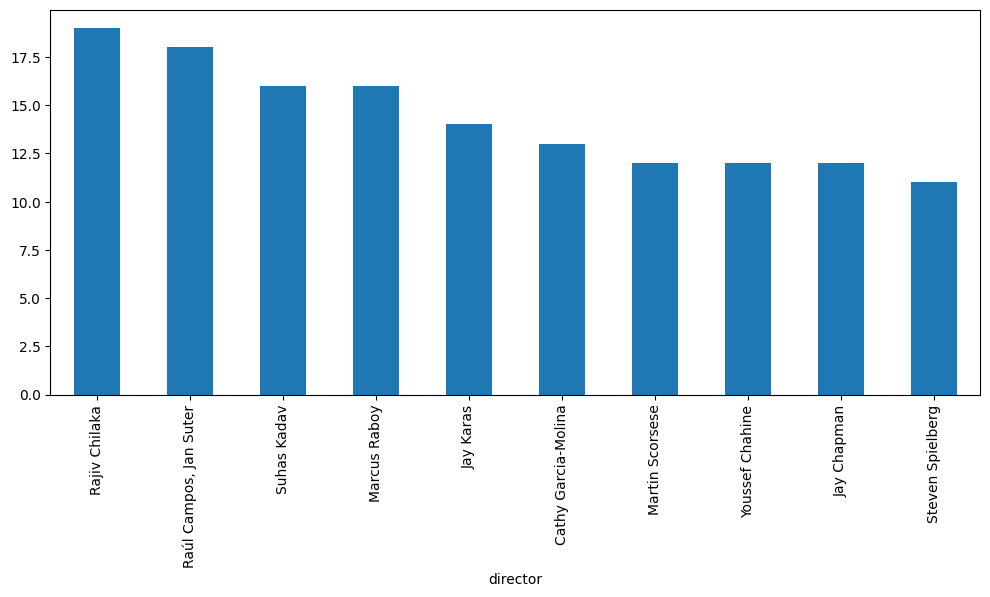

In [ ]:
#Who are the most frequent directors and lead actors in the dataset?
df[df["director"] != "Unspecified"]["director"].value_counts().head(10).plot(kind="bar", figsize=(12,5))

In [ ]:

df_country_explode = df.assign(country_explode=df["country"].str.split(",")).explode("country_explode")
df_country_explode["country_explode"] = df_country_explode["country_explode"].str.strip()

In [ ]:
df_country_explode.sample(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,country_explode
6153,s6154,Movie,An American Tail: The Mystery of the Night Mon...,Larry Latham,"Thomas Dekker, Lacey Chabert, Jane Singer, Neh...",United States,"April 1, 2018",1999,G,75 min,Children & Family Movies,When a monster goes on a mouse-napping spree i...,United States
1,s2,TV Show,Blood & Water,Unspecified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",South Africa
2221,s2222,Movie,Jack Whitehall: I'm Only Joking,"Dave Skinner, Freddie Waters",Jack Whitehall,United Kingdom,"July 21, 2020",2020,TV-MA,58 min,Stand-Up Comedy,Jack Whitehall hits the stage with hilarious t...,United Kingdom
4096,s4097,Movie,Studio 54,Matt Tyrnauer,Unspecified,United States,"February 16, 2019",2018,TV-MA,99 min,Documentaries,This documentary follows the rapid rise and fa...,United States
163,s164,Movie,My Boss's Daughter,David Zucker,"Ashton Kutcher, Tara Reid, Jeffrey Tambor, And...",United States,"September 1, 2021",2003,R,86 min,"Comedies, Romantic Movies","A young man house-sits for his mean boss, hopi...",United States
7283,s7284,Movie,Legend of the Naga Pearls,Yang Lei,"Darren Wang, Zhang Tianai, Sheng Guansen, Simo...",China,"March 30, 2018",2017,TV-MA,108 min,"Action & Adventure, International Movies, Sci-...",A petty thief teams up with two bickering acco...,China
6617,s6618,Movie,District 9,Neill Blomkamp,"Sharlto Copley, Jason Cope, David James, Vanes...","South Africa, United States, New Zealand, Canada","November 4, 2019",2009,R,112 min,"Action & Adventure, International Movies, Sci-...","After years of segregation and forced labor, a...",Canada
4305,s4306,TV Show,Inside the Real Narcos,Unspecified,Jason Fox,Unspecified,"December 14, 2018",2018,TV-MA,1 Season,"British TV Shows, Crime TV Shows, Docuseries",Exposing a rarely seen perspective on the drug...,Unspecified
4405,s4406,TV Show,Super Drags,Unspecified,"Fernando Mendonça, Sérgio Cantú, Wagner Follar...",Brazil,"November 9, 2018",2018,TV-MA,1 Season,"International TV Shows, TV Comedies","In this adult animated series, three gay co-wo...",Brazil
5063,s5064,TV Show,The Adventures of Puss in Boots,Unspecified,"Eric Bauza, Jayma Mays, Grey DeLisle, Paul Rug...",United States,"January 26, 2018",2018,TV-Y7,6 Seasons,"Kids' TV, TV Comedies","The world's greatest feline fighter, lover and...",United States


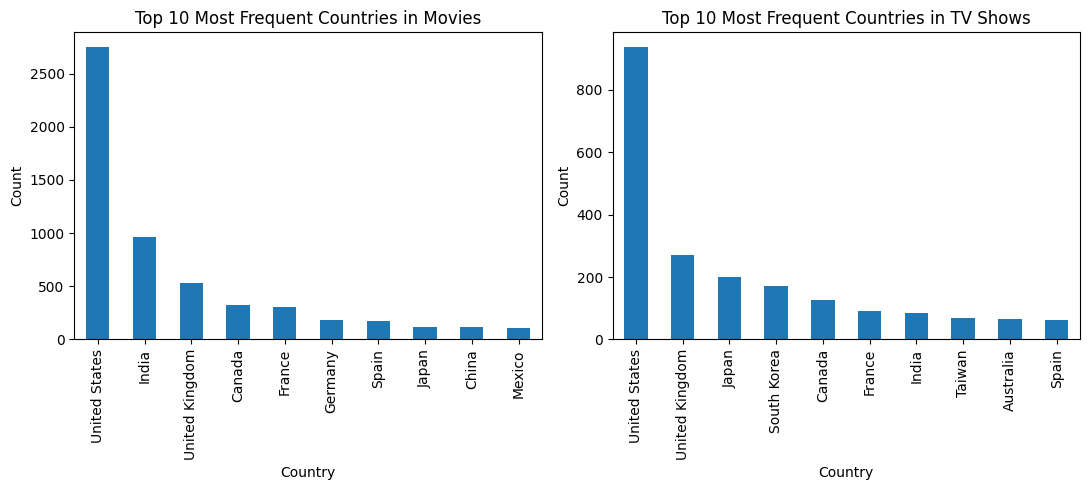

In [ ]:
fig, axes = plt.subplots(1 ,2 , figsize = (11, 5))
df_country_explode[(df_country_explode["type"] == "Movie") & (df_country_explode["country_explode"] !=  "Unspecified")]["country_explode"].value_counts().head(10).plot(kind = "bar", ax = axes[0])
axes[0].set_title("Top 10 Most Frequent Countries in Movies")
axes[0].set_xlabel("Country")
axes[0].set_ylabel("Count")

df_country_explode[(df_country_explode["type"] == "TV Show") & (df_country_explode["country_explode"] !=  "Unspecified")]["country_explode"].value_counts().head(10).plot(kind = "bar", ax = axes[1])
axes[1].set_title("Top 10 Most Frequent Countries in TV Shows")
axes[1].set_xlabel("Country")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
df["df_add_year"] = pd.to_datetime(df["date_added"], errors='coerce').dt.year

In [ ]:
df_trend = df.groupby("df_add_year").size().reset_index(name="count").asscending = False

In [ ]:
df_trend = df.groupby("df_add_year").size().reset_index(name="count").sort_values(by="df_add_year")
df_trend_type = df.groupby(["df_add_year","type"]).size().reset_index(name="count").sort_values(by="df_add_year")

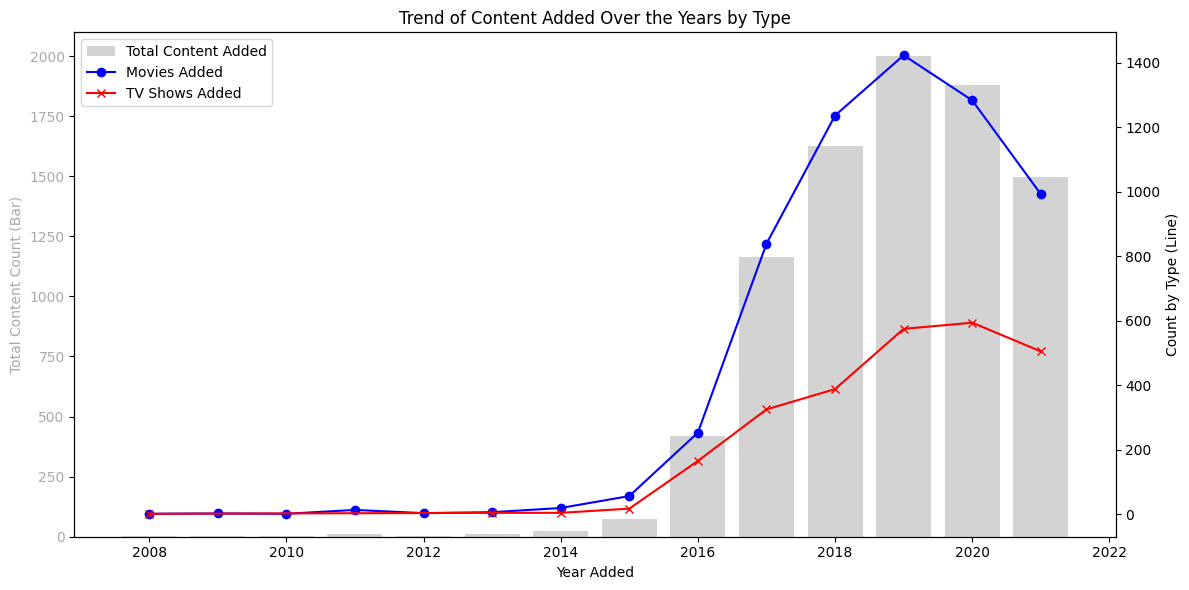

In [ ]:
fig, ax1 = plt.subplots(figsize=(12, 6))

ax1.bar(df_trend["df_add_year"], df_trend["count"], color='lightgray', label='Total Content Added', width=0.8)
ax1.set_xlabel('Year Added')
ax1.set_ylabel('Total Content Count (Bar)', color='darkgray')
ax1.tick_params(axis='y', labelcolor='darkgray')
ax1.set_title('Trend of Content Added Over the Years by Type')

# Create a second y-axis for the line plots
ax2 = ax1.twinx()

# Filter df_trend_type for Movies and TV Shows
df_movies_trend = df_trend_type[df_trend_type["type"] == "Movie"]
df_tvshows_trend = df_trend_type[df_trend_type["type"] == "TV Show"]

# Plot Movies as a line on ax2
ax2.plot(df_movies_trend["df_add_year"], df_movies_trend["count"], color='blue', marker='o', label='Movies Added')
# Plot TV Shows as a line on ax2
ax2.plot(df_tvshows_trend["df_add_year"], df_tvshows_trend["count"], color='red', marker='x', label='TV Shows Added')

ax2.set_ylabel('Count by Type (Line)', color='black')
ax2.tick_params(axis='y', labelcolor='black')

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
df["df_add_month"] = pd.to_datetime(df["date_added"], errors='coerce').dt.month
df["df_add_year"] = pd.to_datetime(df["date_added"], errors = 'coerce').dt.year

Now, let's create a heatmap using this pivoted table to visualize the content counts across months and years.

In [ ]:
df_month_year_pivot = df.pivot_table(index = "df_add_year", columns="df_add_month", values="show_id", aggfunc="count")

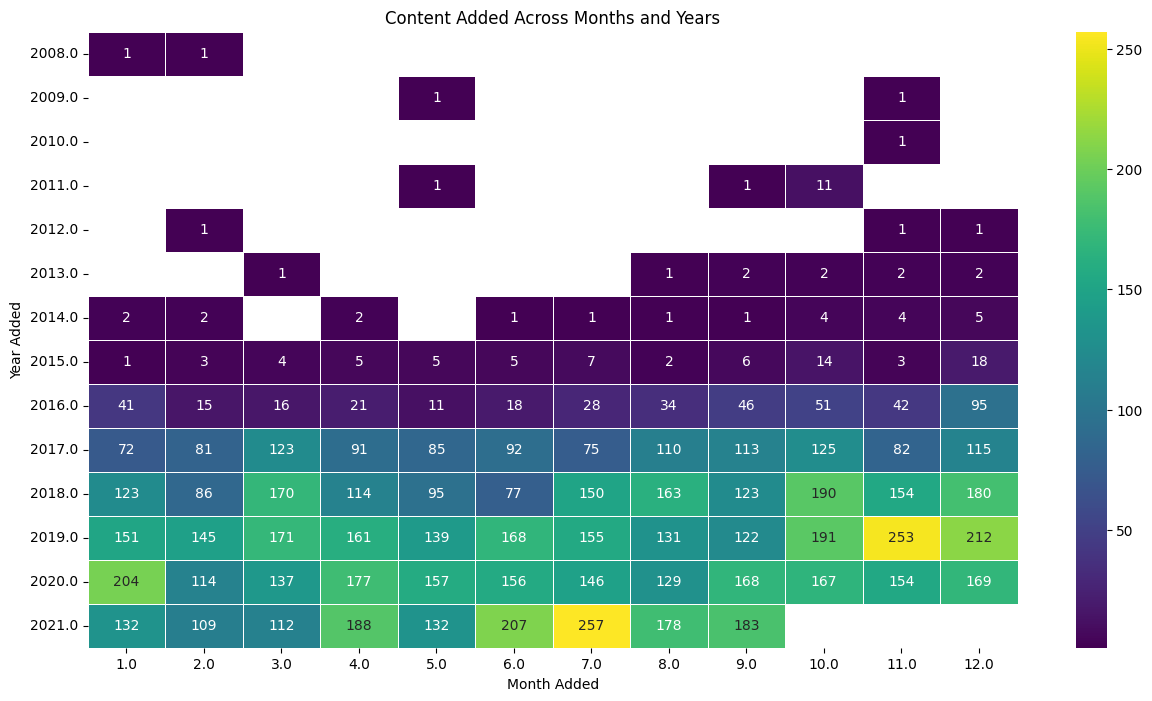

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df_month_year_pivot, cmap='viridis', annot=True, fmt='g', linewidths=.5)
plt.title('Content Added Across Months and Years')
plt.xlabel('Month Added')
plt.ylabel('Year Added')
plt.show()

<Axes: xlabel='country_explode'>

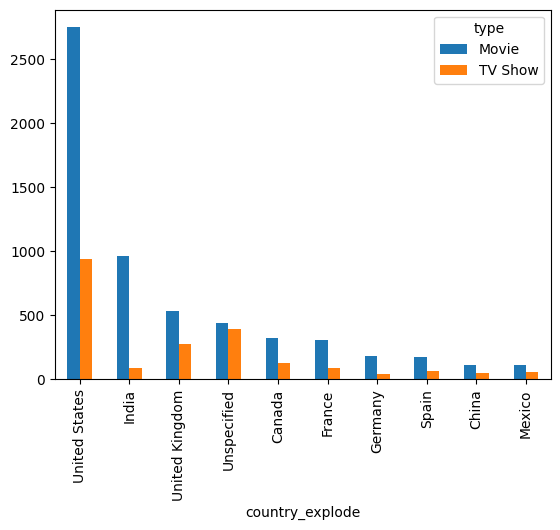

In [ ]:
m = df_country_explode.pivot_table(index="country_explode", columns="type", values="show_id", aggfunc="count")
m.fillna(0, inplace=True)
movie_dominant = m[m["Movie"] > m["TV Show"]][["Movie", "TV Show"]].sort_values(by="Movie", ascending=False).head(10)
movie_dominant.plot(kind="bar")

Single-country productions: Axes(0.125,0.11;0.352273x0.77)
International co-productions: Axes(0.547727,0.11;0.352273x0.77)


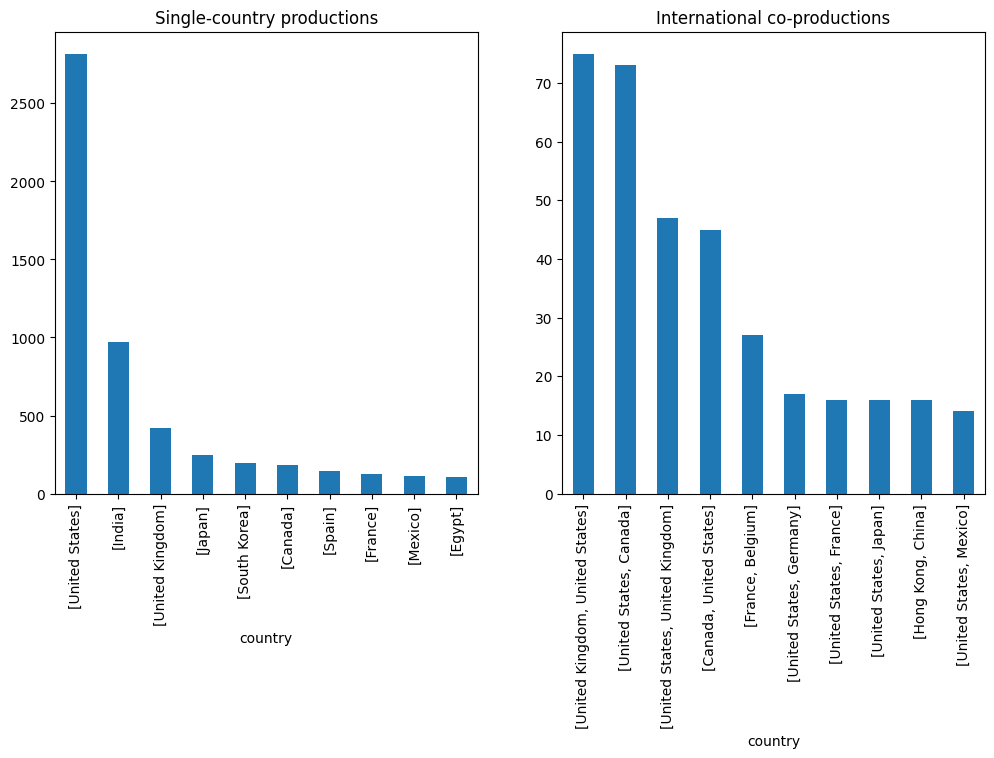

In [ ]:
df_country_split = df[df['country']!="Unspecified"]["country"].apply(lambda x: [c.strip() for c in x.split(',')])
fig, axes = plt.subplots(1,2, figsize=(12,6))
single_country_productions = df_country_split[df_country_split.apply(len) == 1].value_counts().head(10).plot(kind='bar', ax= axes[0])
axes[0].set_title("Single-country productions")
co_productions = df_country_split[df_country_split.apply(len) > 1].value_counts().head(10).plot(kind='bar', ax = axes[1])
axes[1].set_title("International co-productions")
print(f"Single-country productions: {single_country_productions}")
print(f"International co-productions: {co_productions}")

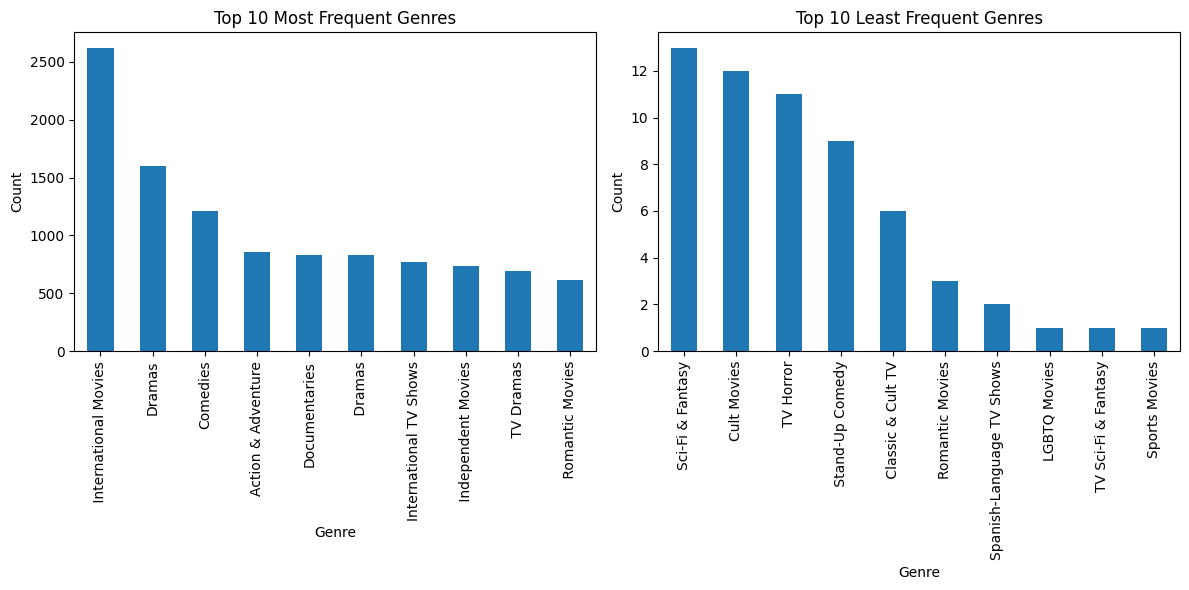

In [ ]:
# What are the most dominant genres across the entire catalog?.
df_genre_analysis = df.assign(genre=df["listed_in"].str.split(",")).explode('genre')
plt, axes = plt.subplots(1,2, figsize=(12,6))
df_genre_analysis["genre"].value_counts().head(10).plot(kind = "bar", ax = axes[0])
axes[0].set_title("Top 10 Most Frequent Genres")
axes[0].set_xlabel("Genre")
axes[0].set_ylabel("Count")

df_genre_analysis['genre'].value_counts().tail(10).plot(kind= "bar", ax = axes[1])
axes[1].set_title("Top 10 Least Frequent Genres")
axes[1].set_xlabel("Genre")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()



<Axes: xlabel='genre'>

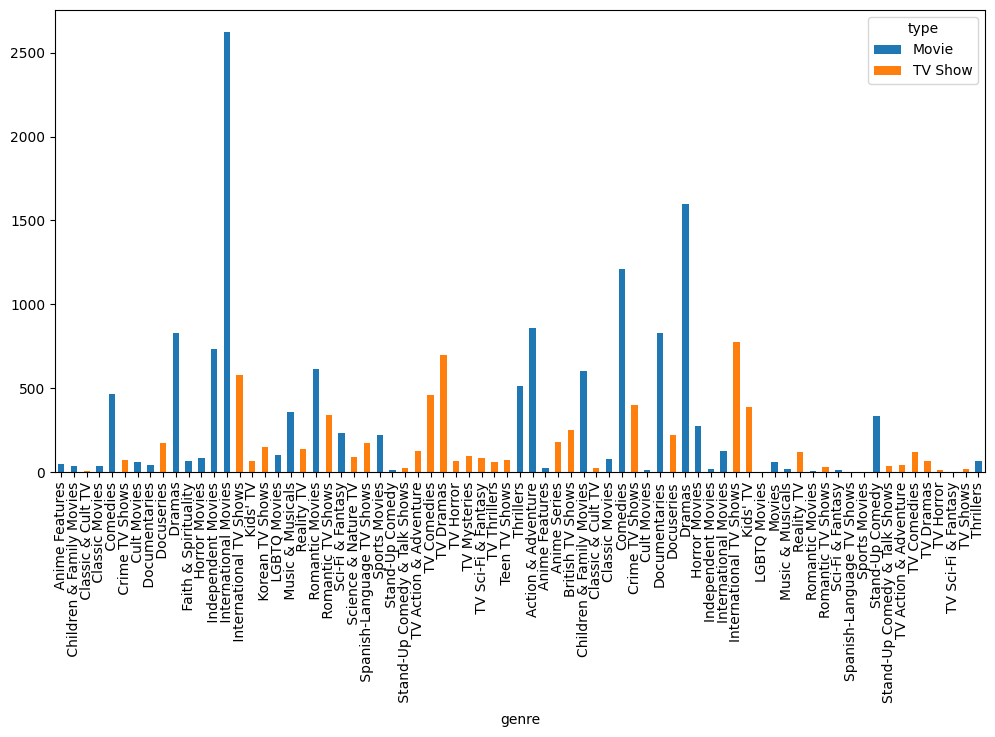

In [ ]:
# How do genre distributions differ between Movies and TV Shows?
df_genre_analysis.groupby(['genre','type']).size().unstack(fill_value = 0).plot(kind='bar', stacked=True, figsize=(12,6))

In [ ]:
#How is content distributed across target age demographics (Adult, Teen, Kids)?
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'Unrated', 'TV-Y7-FV'], dtype=object)

In [ ]:
def get_audience(rating):
    if rating in ["TV-MA", "R", "NC-17"]:
        return "adult"
    elif rating in ["PG-13", "TV-14"]:
        return "teen"
    else:
        return "kids"

df["target_audience"] = df["rating"].apply(get_audience)


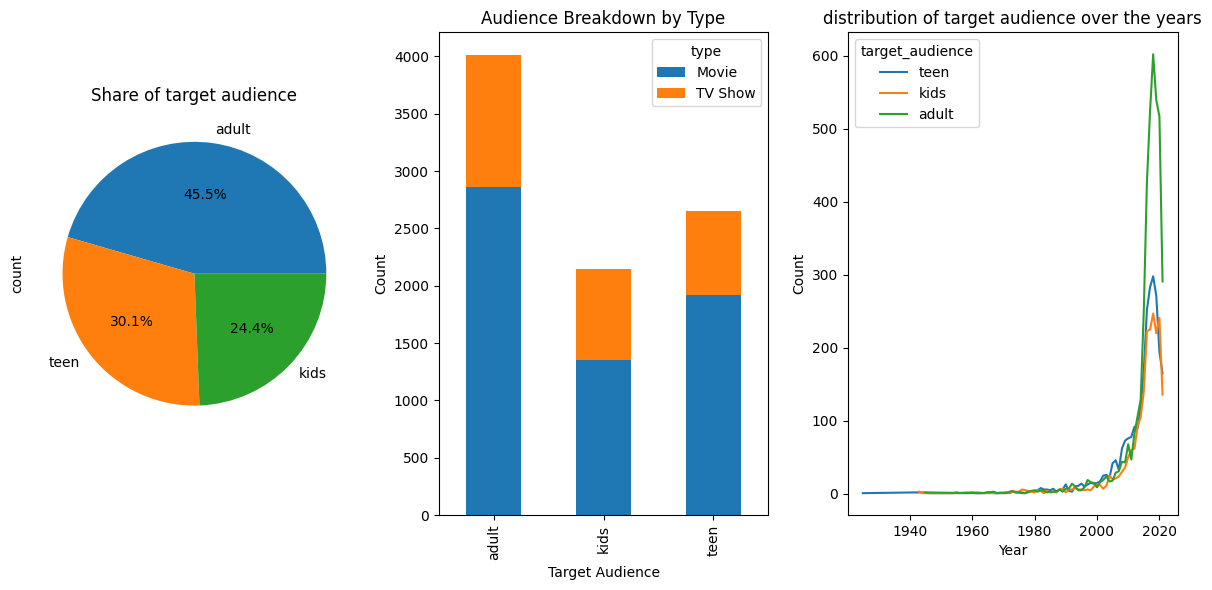

In [ ]:
import matplotlib.pyplot as plt
df_counts = df.groupby(["release_year", "target_audience"]).size().reset_index(name="show_count")
fig, axes = plt.subplots(1,3, figsize=(12,6))

df["target_audience"].value_counts().plot(kind="pie", autopct="%.1f%%", ax = axes[0])
axes[0].set_title("Share of target audience")

pd.crosstab(df["target_audience"], df["type"]).plot(kind="bar", stacked=True, ax = axes[1])
axes[1].set_title("Audience Breakdown by Type")
axes[1].set_xlabel("Target Audience")
axes[1].set_ylabel("Count")

sns.lineplot(data=df_counts, x="release_year", y="show_count", hue="target_audience", ax = axes[2])
axes[2].set_title("distribution of target audience over the years")
axes[2].set_xlabel("Year")
axes[2].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [ ]:
df

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,df_add_year,df_add_month,target_audience
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unspecified,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021.0,9.0,teen
1,s2,TV Show,Blood & Water,Unspecified,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",2021.0,9.0,adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unspecified,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,2021.0,9.0,adult
3,s4,TV Show,Jailbirds New Orleans,Unspecified,Unspecified,Unspecified,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",2021.0,9.0,adult
4,s5,TV Show,Kota Factory,Unspecified,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,2021.0,9.0,adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a...",2019.0,11.0,adult
8803,s8804,TV Show,Zombie Dumb,Unspecified,Unspecified,Unspecified,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g...",2019.0,7.0,kids
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...,2019.0,11.0,adult
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero...",2020.0,1.0,kids


In [ ]:
#What is the average duration of Movies (in minutes), and is the distribution skewed?
print(f"The average duration of movie : {df[df["duration"].str.contains("min") & (df["type"] == "Movie")]["duration"].str.strip(" min").astype(int).mean()}")
print(f"The skew duration of movie : {df[df["duration"].str.contains("min") & (df["type"] == "Movie")]["duration"].str.strip(" min").astype(int).skew()}")


The average duration of movie : 99.56499755341706
The skew duration of movie : 0.20337565111840317


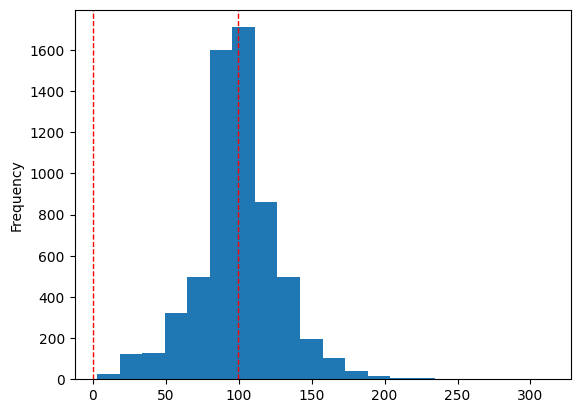

In [ ]:
# What is the typical lifespan of TV Shows (number of seasons)?
df[df["duration"].str.contains("min") & (df["type"] == "Movie")]["duration"].str.strip(" min").astype(int).plot(kind="hist", bins = 20)
plt.axvline(x = 99.56499755341706, color = "red", linewidth = 1, linestyle = "--", label="99.5649975534170629")
plt.axvline(x = 0.20337565111840317, color = "red", linewidth = 1, linestyle = "--", label="0.20337565111840317")


Text(0, 0.5, 'Count')

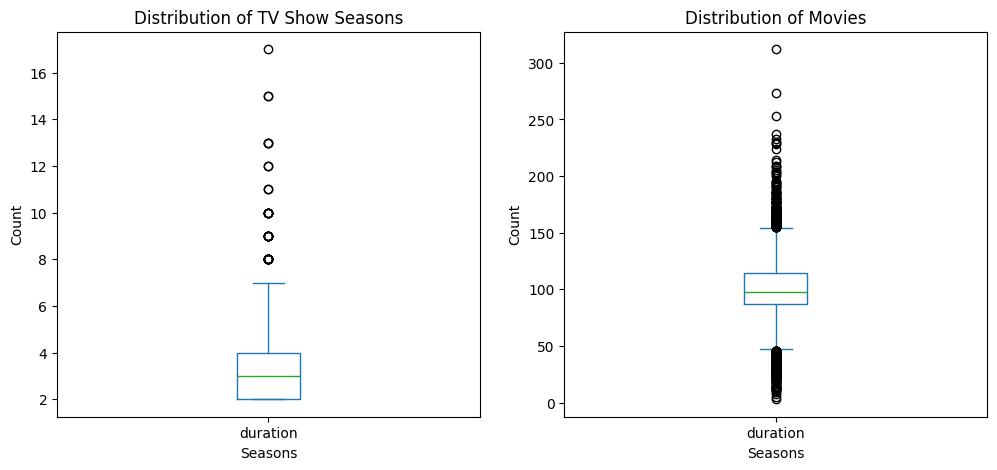

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(12, 5))
df[df["duration"].str.contains("Seasons") & (df["type"] == "TV Show")]["duration"].str.strip("Seasons").astype(int).plot(kind="box", ax = axes[0])
axes[0].set_title("Distribution of TV Show Seasons")
axes[0].set_xlabel("Seasons")
axes[0].set_ylabel("Count")
df[df["duration"].str.contains("min") & (df["type"] == "Movie")]["duration"].str.strip("min").astype(int).plot(kind="box", ax = axes[1])
axes[1].set_title("Distribution of Movies")
axes[1].set_xlabel("Seasons")
axes[1].set_ylabel("Count")

In [ ]:
df_tv_show = df[df["duration"].str.contains("Seasons") & (df["type"] == "TV Show")]["duration"].str.strip("Seasons").astype(int)
df_movie = df[df["duration"].str.contains("min") & (df["type"] == "Movie")]["duration"].str.strip("min").astype(int)

In [ ]:
q1 = df_tv_show.quantile(0.25)
q2 = df_tv_show.quantile(0.75)
iqr = q2 -q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q2 + 1.5 * iqr
upper_bound

q1 = df_movie.quantile(0.25)
q2 = df_movie.quantile(0.75)
iqr = q2 -q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q2 + 1.5 * iqr
lower_bound

np.float64(46.5)

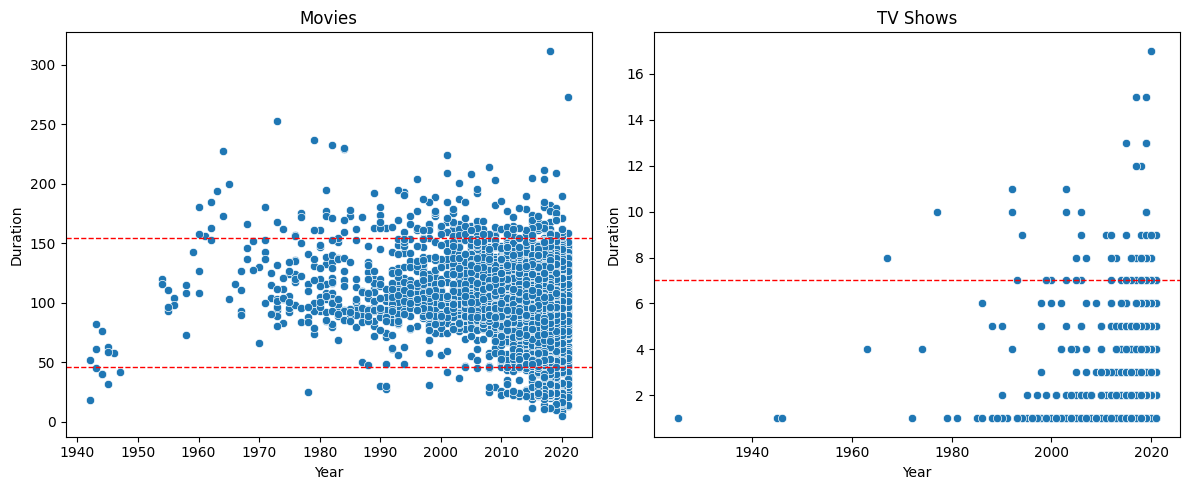

In [ ]:

fig, axes = plt.subplots(1,2, figsize=(12, 5))
sns.scatterplot( y = df[df["type"]  == "Movie"]["duration"].str.strip("min").astype(int), x = df[df["type"]  == "Movie"]["release_year"], data = df, ax = axes[0])
axes[0].axhline(y = 154.5, color = "red", linewidth = 1, linestyle = "--", label="1")
axes[0].axhline(y = 46.5, color = "red", linewidth = 1, linestyle = "--", label="1")
axes[0].set_title("Movies")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Duration")

sns.scatterplot( y = df[df["type"]  == "TV Show"]["duration"].str.strip("Seasons").astype(int), x = df[df["type"]  == "TV Show"]["release_year"], data = df, ax = axes[1])
axes[1].axhline(y = 7.0, color = "red", linewidth = 1, linestyle = "--", label="1")
axes[1].set_title("TV Shows")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Duration")
plt.tight_layout()
plt.show()

In [ ]:
#Which directors work repeatedly with the same cast members?
collaborations= df_exploded.groupby(["director","actor"]).size().reset_index(name='collaboration_count')
frequent_collaborations = (
    collaborations[collaborations['collaboration_count'] > 2]
    .sort_values(by='collaboration_count', ascending=False)
)

print(frequent_collaborations.head(10))

            director               actor  collaboration_count
56017    Unspecified         Unspecified                  352
52782    Unspecified    Takahiro Sakurai                   23
32022  Rajiv Chilaka         Rajesh Kava                   17
32017  Rajiv Chilaka      Jigna Bhardwaj                   17
32018  Rajiv Chilaka       Julie Tejwani                   17
53936    Unspecified           Yuki Kaji                   16
47318    Unspecified      Junichi Suwabe                   16
32023  Rajiv Chilaka        Rupa Bhimani                   16
45155    Unspecified    Fortune Feimster                   16
54641    Unspecified  David Attenborough                   15


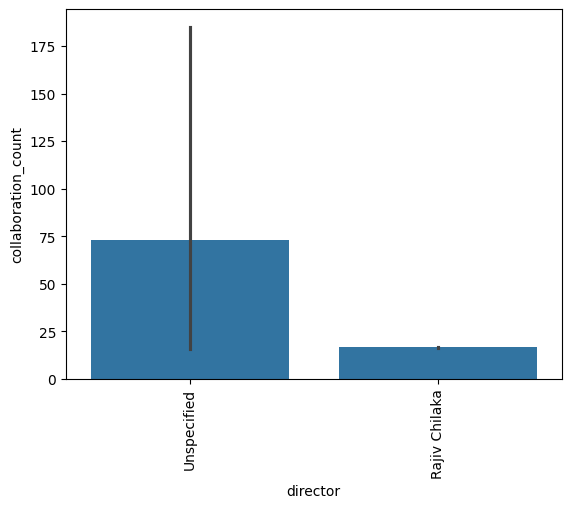

In [ ]:
sns.barplot(data = frequent_collaborations.head(10), x = "director", y = "collaboration_count")
plt.xticks(rotation=90)
plt.show()